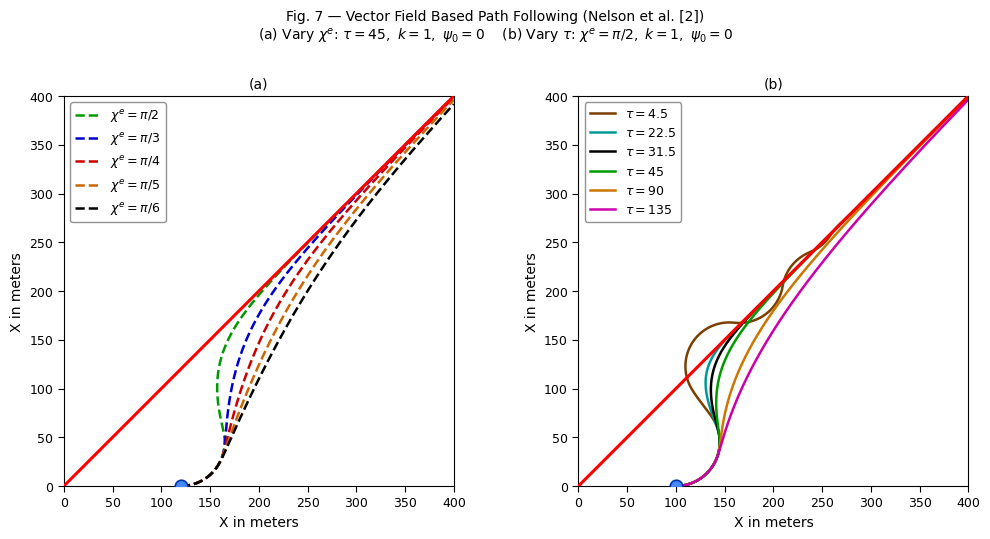

Saved as vf_fig7.png


In [2]:
"""
Vector Field Based Path Following — Fig. 7 replication
Sujit, Saripalli, Sousa — ECC 2013

Run this locally in Jupyter/Colab/Spyder.
The plot is saved as 'vf_fig7.png' in your current working directory.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ─── UAV parameters ──────────────────────────────────────────────────────────
va        = 15.0          # airspeed [m/s]
dt        = 0.005         # time step [s]
R_min     = 45.0          # minimum turning radius [m]
omega_max = va / R_min    # max yaw rate = 0.333 rad/s

theta_path = np.pi / 4    # path angle: 45-degree diagonal y = x

# ─── Helper functions ────────────────────────────────────────────────────────
def wrap(a):
    """Wrap angle to (-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def cross_track_error(x, y, theta_p):
    """
    Signed perpendicular distance from UAV (x,y) to path through origin
    at angle theta_p.
      d > 0 : UAV is LEFT  of path direction
      d < 0 : UAV is RIGHT of path direction
    For path y=x (theta_p=pi/4), UAV at (120,0): d ≈ -84.85 (right/below)
    """
    return -x * np.sin(theta_p) + y * np.cos(theta_p)

def vf_desired_heading(x, y, theta_p, chi_e, tau, k=1.0):
    """
    Vector Field desired course angle — Nelson et al. (2007).

    Formula:
        chi_d = theta_p - chi_e * (2/pi) * arctan((k/tau) * d)

    Behavior:
      |d| >> 0  ->  arctan saturates at ±pi/2  -> chi_d ≈ theta_p ∓ chi_e
                    (UAV flies at entry angle chi_e toward the path)
      d  -> 0   ->  arctan -> 0               -> chi_d -> theta_p
                    (UAV aligns with path direction)

    Parameters:
      chi_e : entry angle (0, pi/2] — steeper = faster approach
      tau   : transition width — larger tau = gentler, slower convergence
      k     : sharpness gain (fixed at 1 in the paper)
    """
    d     = cross_track_error(x, y, theta_p)
    chi_d = theta_p - chi_e * (2.0 / np.pi) * np.arctan((k / tau) * d)
    return chi_d, d

def simulate(x0, y0, psi0, theta_p, chi_e, tau, k=1.0, ctrl_gain=2.0, T=80.0):
    """
    Simulate UAV kinematic model (Dubins car) under VF guidance.

    State:  x, y (position), psi (heading)
    Input:  u = psi_dot, clamped to ±omega_max (physical turn-rate limit)

    Equations of motion (no wind):
      x_dot   = va * cos(psi)
      y_dot   = va * sin(psi)
      psi_dot = clip(ctrl_gain * wrap(chi_d - psi), ±omega_max)
    """
    x, y, psi = x0, y0, psi0
    xs, ys = [x], [y]

    for _ in np.arange(0, T, dt):
        chi_d, _ = vf_desired_heading(x, y, theta_p, chi_e, tau, k)
        err      = wrap(chi_d - psi)
        psi_dot  = np.clip(ctrl_gain * err, -omega_max, omega_max)

        psi = wrap(psi + psi_dot * dt)
        x  += va * np.cos(psi) * dt
        y  += va * np.sin(psi) * dt
        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

def clip_to_bounds(xs, ys, xmin=0, xmax=400, ymin=0, ymax=400):
    """Clip trajectory to plot window (matches paper axes 0–400)."""
    mask = (xs >= xmin) & (xs <= xmax) & (ys >= ymin) & (ys <= ymax)
    return xs[mask], ys[mask]

# ─── Common drawing ──────────────────────────────────────────────────────────
path_pts = np.array([0, 400])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 5.2))

# ════════════════════════════════════════════════════════════════════════════
# Fig 7(a): Vary chi_e | tau=45, k=1, psi0=0, UAV start=(120, 0)
#
# Higher chi_e -> steeper approach angle -> converges faster (joins path sooner)
# Lower  chi_e -> shallower angle        -> converges slower (joins path near end)
# All curves: smooth, no oscillation (tau=45 is large enough for k=1)
# ════════════════════════════════════════════════════════════════════════════
tau_a, k_a = 45.0, 1.0
x0a, y0a   = 120.0, 0.0

cases_a = [
    # (chi_e,      color,      linestyle, legend label,        sim time T)
    (np.pi/2,   '#009900',   '--',   r'$\chi^e=\pi/2$',   75),
    (np.pi/3,   '#0000cc',   '--',   r'$\chi^e=\pi/3$',   80),
    (np.pi/4,   '#cc0000',   '--',   r'$\chi^e=\pi/4$',   85),
    (np.pi/5,   '#cc6600',   '--',   r'$\chi^e=\pi/5$',   90),
    (np.pi/6,   '#000000',   '--',   r'$\chi^e=\pi/6$',   95),
]

for chi_e, color, ls, label, T in cases_a:
    xs, ys = simulate(x0a, y0a, 0.0, theta_path,
                      chi_e, tau_a, k_a, ctrl_gain=2.0, T=T)
    xc, yc = clip_to_bounds(xs, ys)
    ax1.plot(xc, yc, color=color, linestyle=ls, linewidth=1.8, label=label)

ax1.plot(path_pts, path_pts, 'r-', linewidth=2.2, zorder=10)
ax1.plot(x0a, y0a, 'o', color='#1155cc', markersize=9,
         markerfacecolor='#4488ff', markeredgecolor='#0033aa',
         markeredgewidth=1.2, zorder=11)

ax1.set_xlim(0, 400);  ax1.set_ylim(0, 400)
ax1.set_xlabel('X in meters', fontsize=10)
ax1.set_ylabel('X in meters', fontsize=10)
ax1.set_title('(a)', fontsize=10)
ax1.set_aspect('equal')
ax1.legend(fontsize=9, loc='upper left', framealpha=0.85, edgecolor='gray')
ax1.tick_params(labelsize=9)
ax1.set_xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
ax1.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])

# ════════════════════════════════════════════════════════════════════════════
# Fig 7(b): Vary tau | chi_e=pi/2, k=1, psi0=0, UAV start=(100, 0)
#
# Small tau -> narrow transition zone -> chi_d snaps abruptly -> loop/overshoot
# Large tau -> wide  transition zone  -> chi_d changes smoothly -> slow approach
#
# tau=4.5   (brown)  -> 1 large loop visible in plot window
# tau=22.5  (cyan)   -> smaller overshoot loop
# tau=31.5  (black)  -> marginal overshoot
# tau=45    (green)  -> clean smooth convergence
# tau=90    (orange) -> slow S-curve approach
# tau=135   (magenta)-> very slow wide approach
# ════════════════════════════════════════════════════════════════════════════
chi_e_b, k_b = np.pi/2, 1.0
x0b, y0b     = 100.0, 0.0

cases_b = [
    # (tau,    color,       linestyle, legend label,    sim time T)
    (4.5,    '#7b3f00',   '-',   r'$\tau=4.5$',    80),
    (22.5,   '#009999',   '-',   r'$\tau=22.5$',   75),
    (31.5,   '#000000',   '-',   r'$\tau=31.5$',   75),
    (45.0,   '#009900',   '-',   r'$\tau=45$',     75),
    (90.0,   '#cc7700',   '-',   r'$\tau=90$',     80),
    (135.0,  '#cc00aa',   '-',   r'$\tau=135$',    90),
]

for tau, color, ls, label, T in cases_b:
    xs, ys = simulate(x0b, y0b, 0.0, theta_path,
                      chi_e_b, tau, k_b, ctrl_gain=2.0, T=T)
    xc, yc = clip_to_bounds(xs, ys)
    ax2.plot(xc, yc, color=color, linestyle=ls, linewidth=1.8, label=label)

ax2.plot(path_pts, path_pts, 'r-', linewidth=2.2, zorder=10)
ax2.plot(x0b, y0b, 'o', color='#1155cc', markersize=9,
         markerfacecolor='#4488ff', markeredgecolor='#0033aa',
         markeredgewidth=1.2, zorder=11)

ax2.set_xlim(0, 400);  ax2.set_ylim(0, 400)
ax2.set_xlabel('X in meters', fontsize=10)
ax2.set_ylabel('X in meters', fontsize=10)
ax2.set_title('(b)', fontsize=10)
ax2.set_aspect('equal')
ax2.legend(fontsize=9, loc='upper left', framealpha=0.85, edgecolor='gray')
ax2.tick_params(labelsize=9)
ax2.set_xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
ax2.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])

# ─── Figure title and save ───────────────────────────────────────────────────
fig.suptitle(
    'Fig. 7 — Vector Field Based Path Following (Nelson et al. [2])\n'
    r'(a) Vary $\chi^e$: $\tau=45,\ k=1,\ \psi_0=0$    '
    r'(b) Vary $\tau$: $\chi^e=\pi/2,\ k=1,\ \psi_0=0$',
    fontsize=10, y=1.01)

plt.tight_layout(pad=1.5)

# ── SAVE: change this path to wherever you want the file ──────────────────
plt.savefig('vf_fig7.png', dpi=180, bbox_inches='tight')   # saves in CWD
# plt.savefig('/content/vf_fig7.png', dpi=180, bbox_inches='tight')  # Colab
# plt.savefig('C:/Users/YourName/Desktop/vf_fig7.png', dpi=180)      # Windows

plt.show()
print("Saved as vf_fig7.png")

                              VECTOR FIELD GUIDANCE LAW PERFORMANCE METRICS DASHBOARD                              

--- [A] VECTOR FIELD PERMANENT PERFORMANCE (VARYING ENTRY ANGLE χᵉ) ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
-------------------------------------------------------------------------------------------------------------------
\chi^e=\pi/2 |   10.543m |   98.007m |   28.037m |     0.000m | 14.27 s           | 16.46 s          
\chi^e=\pi/3 |   11.664m |   98.007m |   28.551m |     0.000m | 18.82 s           | 22.44 s          
\chi^e=\pi/4 |   12.960m |   98.007m |   29.402m |     0.000m | 23.75 s           | 28.77 s          
\chi^e=\pi/5 |   14.250m |   98.007m |   30.328m |     0.001m | 28.84 s           | 35.24 s          
\chi^e=\pi/6 |   15.473m |   98.007m |   31.229m |     0.004m | 34.01 s           | 41.80 s          

--- [B] VECTOR FIELD PERMANENT PERFORMANCE (VARYING TRANSITION WIDTH τ) ---
Co

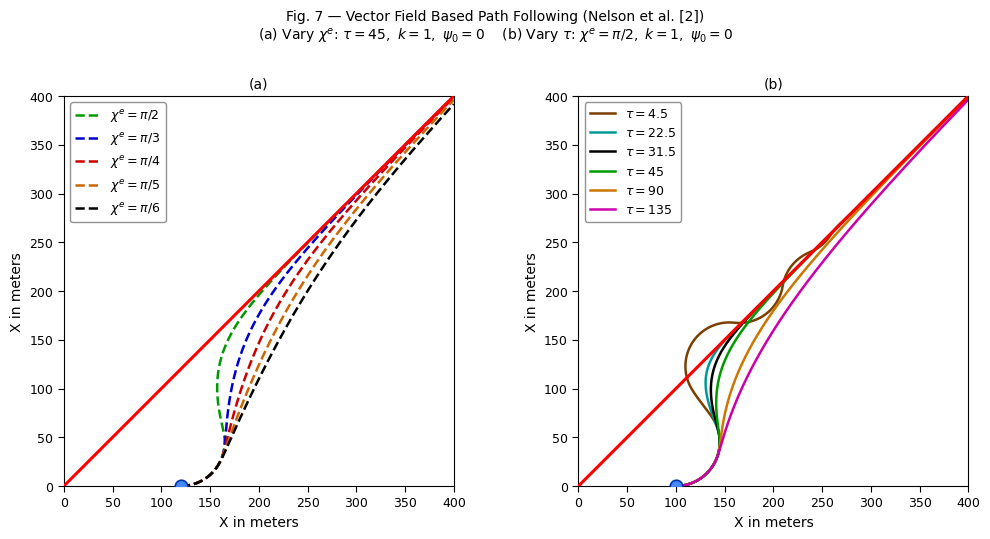

Saved as vf_fig7.png


In [1]:
# -*- coding: utf-8 -*-
"""vector field.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/17X9ekBJOMPjEWlRqRHBtAa02UFuhVK5g
"""

"""
Vector Field Based Path Following — Fig. 7 replication
Sujit, Saripalli, Sousa — ECC 2013

Run this locally in Jupyter/Colab/Spyder.
The plot is saved as 'vf_fig7.png' in your current working directory.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ─── UAV parameters ──────────────────────────────────────────────────────────
va        = 15.0          # airspeed [m/s]
dt        = 0.005         # time step [s]
R_min     = 45.0          # minimum turning radius [m]
omega_max = va / R_min    # max yaw rate = 0.333 rad/s

theta_path = np.pi / 4    # path angle: 45-degree diagonal y = x

# ─── Helper functions ────────────────────────────────────────────────────────
def wrap(a):
    """Wrap angle to (-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def cross_track_error(x, y, theta_p):
    """
    Signed perpendicular distance from UAV (x,y) to path through origin
    at angle theta_p.
      d > 0 : UAV is LEFT  of path direction
      d < 0 : UAV is RIGHT of path direction
    For path y=x (theta_p=pi/4), UAV at (120,0): d ≈ -84.85 (right/below)
    """
    return -x * np.sin(theta_p) + y * np.cos(theta_p)

def vf_desired_heading(x, y, theta_p, chi_e, tau, k=1.0):
    """
    Vector Field desired course angle — Nelson et al. (2007).

    Formula:
        chi_d = theta_p - chi_e * (2/pi) * arctan((k/tau) * d)

    Behavior:
      |d| >> 0  ->  arctan saturates at ±pi/2  -> chi_d ≈ theta_p ∓ chi_e
                    (UAV flies at entry angle chi_e toward the path)
      d  -> 0   ->  arctan -> 0               -> chi_d -> theta_p
                    (UAV aligns with path direction)

    Parameters:
      chi_e : entry angle (0, pi/2] — steeper = faster approach
      tau   : transition width — larger tau = gentler, slower convergence
      k     : sharpness gain (fixed at 1 in the paper)
    """
    d     = cross_track_error(x, y, theta_p)
    chi_d = theta_p - chi_e * (2.0 / np.pi) * np.arctan((k / tau) * d)
    return chi_d, d

def simulate(x0, y0, psi0, theta_p, chi_e, tau, k=1.0, ctrl_gain=2.0, T=80.0):
    """
    Simulate UAV kinematic model (Dubins car) under VF guidance.

    State:  x, y (position), psi (heading)
    Input:  u = psi_dot, clamped to ±omega_max (physical turn-rate limit)

    Equations of motion (no wind):
      x_dot   = va * cos(psi)
      y_dot   = va * sin(psi)
      psi_dot = clip(ctrl_gain * wrap(chi_d - psi), ±omega_max)
    """
    x, y, psi = x0, y0, psi0
    xs, ys = [x], [y]

    for _ in np.arange(0, T, dt):
        chi_d, _ = vf_desired_heading(x, y, theta_p, chi_e, tau, k)
        err      = wrap(chi_d - psi)
        psi_dot  = np.clip(ctrl_gain * err, -omega_max, omega_max)

        psi = wrap(psi + psi_dot * dt)
        x  += va * np.cos(psi) * dt
        y  += va * np.sin(psi) * dt
        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

def clip_to_bounds(xs, ys, xmin=0, xmax=400, ymin=0, ymax=400):
    """Clip trajectory to plot window (matches paper axes 0–400)."""
    mask = (xs >= xmin) & (xs <= xmax) & (ys >= ymin) & (ys <= ymax)
    return xs[mask], ys[mask]

# =============================================================================
# ERROR ANALYSIS METRICS HELPER FUNCTIONS
# =============================================================================
def calculate_settling_time(xte_array, threshold, time_step=dt):
    """Finds the time when XTE drops below a threshold and remains there permanently."""
    above_threshold_indices = np.where(xte_array >= threshold)[0]
    if len(above_threshold_indices) == 0:
        return 0.0  # Settled from step 0

    last_above_index = above_threshold_indices[-1]
    # If the absolute final index of the timeline exceeds the threshold boundary, convergence failed
    if last_above_index == len(xte_array) - 1:
        return None

    return (last_above_index + 1) * time_step

def compute_vf_line_errors(xs, ys, theta_p=theta_path):
    """Calculates spatial tracking errors relative to the diagonal line path"""
    xte = np.abs(-xs * np.sin(theta_p) + ys * np.cos(theta_p))
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m


# ─── Common drawing ──────────────────────────────────────────────────────────
path_pts = np.array([0, 400])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 5.2))

print("=" * 115)
print(f"{'VECTOR FIELD GUIDANCE LAW PERFORMANCE METRICS DASHBOARD':^115}")
print("=" * 115)

# ════════════════════════════════════════════════════════════════════════════
# Fig 7(a): Vary chi_e | tau=45, k=1, psi0=0, UAV start=(120, 0)
#
# Higher chi_e -> steeper approach angle -> converges faster (joins path sooner)
# Lower  chi_e -> shallower angle        -> converges slower (joins path near end)
# All curves: smooth, no oscillation (tau=45 is large enough for k=1)
# ════════════════════════════════════════════════════════════════════════════
tau_a, k_a = 45.0, 1.0
x0a, y0a   = 120.0, 0.0

cases_a = [
    # (chi_e,      color,      linestyle, legend label,        sim time T)
    (np.pi/2,   '#009900',   '--',   r'$\chi^e=\pi/2$',   75),
    (np.pi/3,   '#0000cc',   '--',   r'$\chi^e=\pi/3$',   80),
    (np.pi/4,   '#cc0000',   '--',   r'$\chi^e=\pi/4$',   85),
    (np.pi/5,   '#cc6600',   '--',   r'$\chi^e=\pi/5$',   90),
    (np.pi/6,   '#000000',   '--',   r'$\chi^e=\pi/6$',   95),
]

print("\n--- [A] VECTOR FIELD PERMANENT PERFORMANCE (VARYING ENTRY ANGLE \u03c7\u1d49) ---")
header = f"{'Config':<12} | {'Mean XTE':<10} | {'Max XTE':<10} | {'RMSE':<10} | {'Final XTE':<11} | {'Settle Time (5m)':<17} | {'Settle Time (2m)':<17}"
print(header)
print("-" * 115)

for chi_e, color, ls, label, T in cases_a:
    xs, ys = simulate(x0a, y0a, 0.0, theta_path,
                      chi_e, tau_a, k_a, ctrl_gain=2.0, T=T)
    xc, yc = clip_to_bounds(xs, ys)
    ax1.plot(xc, yc, color=color, linestyle=ls, linewidth=1.8, label=label)

    # Calculate performance metrics on complete continuous flight parameters
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_vf_line_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"

    # Formatting clean labels for output table representation
    cfg_lbl = label.replace('r$', '').replace('$', '')
    print(f"{cfg_lbl:<12} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

ax1.plot(path_pts, path_pts, 'r-', linewidth=2.2, zorder=10)
ax1.plot(x0a, y0a, 'o', color='#1155cc', markersize=9,
         markerfacecolor='#4488ff', markeredgecolor='#0033aa',
         markeredgewidth=1.2, zorder=11)

ax1.set_xlim(0, 400);  ax1.set_ylim(0, 400)
ax1.set_xlabel('X in meters', fontsize=10)
ax1.set_ylabel('X in meters', fontsize=10)
ax1.set_title('(a)', fontsize=10)
ax1.set_aspect('equal')
ax1.legend(fontsize=9, loc='upper left', framealpha=0.85, edgecolor='gray')
ax1.tick_params(labelsize=9)
ax1.set_xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
ax1.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])

# ════════════════════════════════════════════════════════════════════════════
# Fig 7(b): Vary tau | chi_e=pi/2, k=1, psi0=0, UAV start=(100, 0)
#
# Small tau -> narrow transition zone -> chi_d snaps abruptly -> loop/overshoot
# Large tau -> wide  transition zone  -> chi_d changes smoothly -> slow approach
#
# tau=4.5   (brown)  -> 1 large loop visible in plot window
# tau=22.5  (cyan)   -> smaller overshoot loop
# tau=31.5  (black)  -> marginal overshoot
# tau=45    (green)  -> clean smooth convergence
# tau=90    (orange) -> slow S-curve approach
# tau=135   (magenta)-> very slow wide approach
# ════════════════════════════════════════════════════════════════════════════
chi_e_b, k_b = np.pi/2, 1.0
x0b, y0b     = 100.0, 0.0

cases_b = [
    # (tau,    color,       linestyle, legend label,    sim time T)
    (4.5,    '#7b3f00',   '-',   r'$\tau=4.5$',    80),
    (22.5,   '#009999',   '-',   r'$\tau=22.5$',   75),
    (31.5,   '#000000',   '-',   r'$\tau=31.5$',   75),
    (45.0,   '#009900',   '-',   r'$\tau=45$',     75),
    (90.0,   '#cc7700',   '-',   r'$\tau=90$',     80),
    (135.0,  '#cc00aa',   '-',   r'$\tau=135$',    90),
]

print("\n--- [B] VECTOR FIELD PERMANENT PERFORMANCE (VARYING TRANSITION WIDTH \u03c4) ---")
print(header)
print("-" * 115)

for tau, color, ls, label, T in cases_b:
    xs, ys = simulate(x0b, y0b, 0.0, theta_path,
                      chi_e_b, tau, k_b, ctrl_gain=2.0, T=T)
    xc, yc = clip_to_bounds(xs, ys)
    ax2.plot(xc, yc, color=color, linestyle=ls, linewidth=1.8, label=label)

    # Calculate performance metrics on complete continuous flight parameters
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_vf_line_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"

    # Formatting clean labels for output table representation
    cfg_lbl = label.replace('r$', '').replace('$', '')
    print(f"{cfg_lbl:<12} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

ax2.plot(path_pts, path_pts, 'r-', linewidth=2.2, zorder=10)
ax2.plot(x0b, y0b, 'o', color='#1155cc', markersize=9,
         markerfacecolor='#4488ff', markeredgecolor='#0033aa',
         markeredgewidth=1.2, zorder=11)

ax2.set_xlim(0, 400);  ax2.set_ylim(0, 400)
ax2.set_xlabel('X in meters', fontsize=10)
ax2.set_ylabel('X in meters', fontsize=10)
ax2.set_title('(b)', fontsize=10)
ax2.set_aspect('equal')
ax2.legend(fontsize=9, loc='upper left', framealpha=0.85, edgecolor='gray')
ax2.tick_params(labelsize=9)
ax2.set_xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
ax2.set_yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])

# ─── Figure title and save ───────────────────────────────────────────────────
fig.suptitle(
    'Fig. 7 — Vector Field Based Path Following (Nelson et al. [2])\n'
    r'(a) Vary $\chi^e$: $\tau=45,\ k=1,\ \psi_0=0$    '
    r'(b) Vary $\tau$: $\chi^e=\pi/2,\ k=1,\ \psi_0=0$',
    fontsize=10, y=1.01)

plt.tight_layout(pad=1.5)

# ── SAVE: change this path to wherever you want the file ──────────────────
plt.savefig('vf_fig7.png', dpi=180, bbox_inches='tight')   # saves in CWD
# plt.savefig('/content/vf_fig7.png', dpi=180, bbox_inches='tight')  # Colab
# plt.savefig('C:/Users/YourName/Desktop/vf_fig7.png', dpi=180)      # Windows

print("\n" + "=" * 115)
plt.show()
print("Saved as vf_fig7.png")